# Policy Optimization
This notebook demonstrates how metaheuristic search can be used to optimize the holding policies in effect along a fixed-line transit route. We compare with two baselines: Liu et al. [1] and Zhao et al. [2], as well as a completely uncontrolled route.

[1] S. Liu, X. Luo, and P. J. Jin, "Improving bus operations through integrated dynamic holding control and schedule optimization," *Journal of Advanced Trasportation*, vol. 2018, no. 1, p. 9714046, 2018.

[2] L. Zhao, S. I. Chien, L. N. Spasovic, and X. Liu, "Modeling and optimizing urban bus transit considering headway variation for cost and service reliability analysis," *Transporation Planning and Technology*, vol. 41, no. 7, pp. 706-723. 2018.

In [1]:
from copy import deepcopy
from math import sqrt
from os import path
from time import time

from plotly import graph_objects
from plotly import express

from analysis.gtfs_utils import load_route_from_gtfs, load_times
from analysis.policies import BolehPolicy, HeadwayDrivenPolicy, InfiniteSchedulePolicy, SlackDrivenPolicy
from analysis.routes import HeadwayResults, RouteConfig, RouteResults, route_factory
from analysis.prob_analysis import simulate
from analysis.wc_analysis import headway_bounds

import numpy
import pygad

## Load a Route from a GTFS

In [2]:
BASE_ROUTE, START_TIMES = load_route_from_gtfs(route_id=55, service_day='monday')
BASE_ROUTE = load_times(BASE_ROUTE, service_day='Monday', lower_quantile=0.05, upper_quantile=0.95)

## Shared Experiment Parameters

In [3]:
# The following are the only stops allowed to be considered for control during headway optimization:
CTRL_PTS = ['HICHICNN', 'MXIBELL', 'MXIGLENG', 'MXITHOMP', 'MCC4_13', 'MXOTHOMP', 'MXOGLENG', 'MXOBELL']


# The following are additional route parameters that form a set of optimization constraints on the optimization variables' domains:

# Number of buses
N_BUSES = 16

# Minimum layover time
L_MIN = 20

# Maximum holding time for the dynamic holding policy
MAX_HOLD = 60

# Minimum and maximum travel time along a route (excluding worst-case schedule holding with bunched buses)
MIN_TRAVEL = sum([min(*s.tau) + min(*s.delta) for s in BASE_ROUTE])
MAX_TRAVEL = sum([max(*s.tau) + max(*s.delta) for s in BASE_ROUTE]) + MAX_HOLD

# Minimum and maximum offset for for scheduled holds
MIN_CTRL = [0 for _ in CTRL_PTS]
MAX_CTRL = [0 for _ in CTRL_PTS]
finished = [False for _ in CTRL_PTS]
for stop in BASE_ROUTE:
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if not finished[idx]:
            MIN_CTRL[idx] += (min(*stop.tau) + min(*stop.delta))
            MAX_CTRL[idx] += (max(*stop.tau) + max(*stop.tau))
        if stop.stop_id == ctrl_pt:
            finished[idx] = True
            MAX_CTRL[idx] += MAX_HOLD


# GA Parameters
T_MAX = 60 * 24
POPULATION_SIZE = 20
MATING_PAIRS = 10
GENERATIONS = 20
MUTATION_PCNT = 10
STOP_CRITERIA = "saturate_5"

## Method 1: Liu et al.
Constructs a unique slack driven policy at each stop.

In [4]:
# Define the gene pool
gene_space = []
for stop in BASE_ROUTE:
    # Slack time at each stop (d)
    gene_space.append({"low": 0.0, "high": MAX_HOLD})
for stop in BASE_ROUTE:
    # Control coefficient (f)
    gene_space.append({"low": 0.0, "high": 1.0})
for stop in CTRL_PTS:
    # Whether or not the an eligible control point is used
    gene_space.append([0, 1])

In [5]:
def fitness_liu_et_al(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """Fitness function for Liu et al.'s optimization method.  All variable names are left as close to their corresponding mathematical
    symbols in the paper as possible.

    :param ga: The PyGad GA object.
    :param solution: The list of genes to be evaluated. The indexes are as follows:
        - 0...N-1: slack time at each stop (float [0, MAX_HOLD])
        - N-1...2N-1: control coefficient at each stop (float [0, 1])
        - 2N-1...2N-1 + #ctrl pts.: whether or not to use a control point (bool)
    :param solution_idx: The solution index in PyGad's GA.
    :return: The solution's fitness.
    """
    zeta_wait = 2.1 # Tradeoff between travel and headway hardcoded in paper.
    var_eps = []
    var_AC = []
    eta = []
    d = []
    l = []
    f = []
    ctrl_idx = 0
    for idx, stop in enumerate(BASE_ROUTE):
        d.append(solution[idx])
        f.append(solution[len(BASE_ROUTE) + idx])
        if stop.stop_id in CTRL_PTS:
            eta.append(solution[len(BASE_ROUTE) * 2 + ctrl_idx])
            ctrl_idx += 1
        else:
            eta.append(0)
        var_AC.append((f[idx] ** 2) * var_eps[idx - 1] if idx > 0 else 0)
        var_eps.append(
            var_AC[idx] + stop.travel_var if eta[idx] == 1 or idx == 0 else (1 + 3.5 * stop.arrival_rate / 60) ** 2 * var_eps[idx - 1]
        )
        l.append([1 / len(BASE_ROUTE) for _ in range(len(BASE_ROUTE))])

    H = (
        sum([d[idx] + stop.mean_travel for idx, stop in enumerate(BASE_ROUTE[:-1])]) + L_MIN + 3 * sqrt(var_eps[-1])
    ) / (N_BUSES + sum([3.5 * stop.arrival_rate / 60 for stop in BASE_ROUTE[:-1]]))

    T_wait = []
    for idx, stop in enumerate(BASE_ROUTE):
        T_wait.append(
            ((H - d[idx]) / 2) * (1 + (var_AC[idx] + var_eps[idx]) / ((H - d[idx]) ** 2)) * ((H - d[idx]) / H)
        )
    
    T_wait = sum([stop.arrival_rate * T_wait[idx] for idx, stop in enumerate(BASE_ROUTE)]) / sum([stop.arrival_rate for stop in BASE_ROUTE])
    T_exwait = 0 # Assume 0 since passenger numbers are low
    T_inveh = (
        sum([
            sum([
                sum([
                    stop_i.arrival_rate * l[idx][jdx] * (3.5 * stop_k.arrival_rate / 60 * H + d[kdx] + stop_k.mean_travel) for kdx, stop_k in enumerate(BASE_ROUTE[idx:jdx + 1])
                ]) for jdx in range(idx,len(BASE_ROUTE))
            ]) for idx, stop_i in enumerate(BASE_ROUTE)
        ]) - sum([stop.arrival_rate * (3.5 * stop.arrival_rate / 60 * H + d[idx]) for idx, stop in enumerate(BASE_ROUTE[:-1])]) / 2
    ) / sum([stop.arrival_rate for stop in BASE_ROUTE])
    objective = zeta_wait * (T_wait + T_exwait) + T_inveh
    return -objective # Goal is to minimize objective

In [6]:
ga_liu_et_al = pygad.GA(
    crossover_type='single_point',
    fitness_func=fitness_liu_et_al,
    gene_space=gene_space,
    keep_parents=1,
    mutation_percent_genes=MUTATION_PCNT,
    mutation_type='random',
    num_generations=GENERATIONS,
    num_genes=len(gene_space),
    num_parents_mating=MATING_PAIRS,
    parent_selection_type='sss',
    save_solutions=True,
    sol_per_pop=POPULATION_SIZE,
    stop_criteria=STOP_CRITERIA,   
    suppress_warnings=True,
)

start = time()
ga_liu_et_al.run()
liu_et_al_time = time() - start
liu_et_al_solution, liu_et_al_solution_fitness, liu_et_al_solution_idx = ga_liu_et_al.best_solution()
print(f'Total Optimization Time: {liu_et_al_time}')
print(f'# Generations: {len(ga_liu_et_al.solutions) / POPULATION_SIZE}')

Total Optimization Time: 7.986285448074341
# Generations: 21.0


In [7]:
# Generate a route with the winning solution for analysis
LIU_ROUTE = deepcopy(BASE_ROUTE)

var_eps = []
var_AC = []
eta = []
d = []
l = []
f = []
ctrl_idx = 0
for idx, stop in enumerate(BASE_ROUTE):
    d.append(liu_et_al_solution[idx])
    f.append(liu_et_al_solution[len(BASE_ROUTE) + idx])
    if stop.stop_id in CTRL_PTS:
        eta.append(liu_et_al_solution[len(BASE_ROUTE) * 2 + ctrl_idx])
        ctrl_idx += 1
    else:
        eta.append(0)
    var_AC.append((f[idx] ** 2) * var_eps[idx - 1] if idx > 0 else 0)
    var_eps.append(
        var_AC[idx] + stop.travel_var if eta[idx] == 1 or idx == 0 else (1 + 3.5 * stop.arrival_rate / 60) ** 2 * var_eps[idx - 1]
    )
    l.append([1 / len(BASE_ROUTE) for _ in range(len(BASE_ROUTE))])

H = (
    sum([d[idx] + stop.mean_travel for idx, stop in enumerate(BASE_ROUTE[:-1])]) + L_MIN + 3 * sqrt(var_eps[-1])
) / (N_BUSES + sum([3.5 * stop.arrival_rate / 60 for stop in BASE_ROUTE[:-1]]))

for stop_idx in range(len(LIU_ROUTE)):
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if LIU_ROUTE[stop_idx].stop_id == ctrl_pt:
            if liu_et_al_solution[2 * len(BASE_ROUTE) + CTRL_PTS.index(ctrl_pt)] == 1:
                LIU_ROUTE[stop_idx].policy = SlackDrivenPolicy
                LIU_ROUTE[stop_idx].policy_args = {
                    'headway': H,
                    'scheduled_slack': liu_et_al_solution[stop_idx],
                    'efficiency_coefficient': liu_et_al_solution[len(BASE_ROUTE) + stop_idx],
                    'beta': 3.5 * LIU_ROUTE[stop_idx].arrival_rate / 60
                }

LIU_START_TIMES = [i * H for i in range(N_BUSES)]

## Method 2: Zhao et al.
We ignore their stop placement selection and focus on their schedule optimization given fixed stop locations.

In [8]:
# Define the gene pool
gene_space = [
    # Single gene for scheduled headway
    {"low": N_BUSES / MAX_TRAVEL, "high": N_BUSES / MIN_TRAVEL}
]

In [9]:
def fitness_zhao_et_al(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """Fitness function for Zhao et al.'s optimization method.  We ignore any terms dependent on stop locations and optimize only for
    scheduled headway.  All variables names are left as close to their corresponding mathematical symbols in the paper as possible.

    :param ga: The PyGad GA object.
    :param solution: The list of genes to be evaluated, in this case a single gene for scheduled headway.
    :param solution_idx: The solution index in PyGad's GA.
    :return: The solution's fitness.
    """
    zeta_wait = 2.1 # We are using the same travel time / headway weightage as Liu et al.
    H = solution[0]
    rho = 3.5 / 60 # Average board/alighting time determined by historic APC data.
    t_w = 0
    t_v = 0
    v = []
    b = []
    for idx, stop in enumerate(BASE_ROUTE):
        if idx == 0:
            b.append(0)
            v.append(0)
        else:
            b.append(stop.arrival_rate * H)
            v_tr = stop.travel_var
            l = stop.mean_travel
            v.append((1 + 4 * rho * b[idx - 1] ** 2 + 2 * rho * b[idx]) * v[idx - 1] + l * v_tr)
        t_w += b[idx] * (H / 2 + v[idx] / (2 * H))
    for idx, stop_i in enumerate(BASE_ROUTE):
        for jdx, stop_j in enumerate(BASE_ROUTE):
            if stop_i.stop_id == stop_j.stop_id:
                continue
            t_v += (b[idx] / len(BASE_ROUTE)) * (sum([s.mean_travel for s in BASE_ROUTE[idx:jdx]]) + sum([rho * b[kdx + idx] * (H ** 2 + (1 + 2 * rho * b[idx]) * v[idx]) for kdx, s in enumerate(BASE_ROUTE[idx:jdx])]))
    objective = zeta_wait * t_w + t_v
    return -objective # Goal is to minimize objective

In [10]:
ga_zhao_et_al = pygad.GA(
    crossover_type='single_point',
    fitness_func=fitness_zhao_et_al,
    gene_space=gene_space,
    keep_parents=1,
    mutation_percent_genes=MUTATION_PCNT,
    mutation_type='random',
    num_generations=GENERATIONS,
    num_genes=len(gene_space),
    num_parents_mating=MATING_PAIRS,
    parent_selection_type='sss',
    save_solutions=True,
    sol_per_pop=POPULATION_SIZE,
    stop_criteria=STOP_CRITERIA,   
    suppress_warnings=True,
)

start = time()
ga_zhao_et_al.run()
zhao_et_al_time = time() - start
zhao_et_al_solution, zhao_et_all_solution_fitness, zhao_et_all_solution_idx = ga_zhao_et_al.best_solution()
print(f'Total Optimization Time: {zhao_et_al_time}')
print(f'# Generations: {len(ga_zhao_et_al.solutions) / POPULATION_SIZE}')

Total Optimization Time: 4.1096720695495605
# Generations: 7.0


In [11]:
# Generate a route with the winning solution for analysis
H = zhao_et_al_solution[0]
ZHAO_ROUTE = deepcopy(BASE_ROUTE)
ZHAO_ROUTE[0].policy = InfiniteSchedulePolicy
ZHAO_ROUTE[0].policy_args = {
    'time_delta': H,
    'offset': sum([s.mean_travel + s.mean_dwell for s in ZHAO_ROUTE]) + L_MIN,
}

ZHAO_START_TIMES = [i * H for i in range(N_BUSES)]

## Method 3: Ours
We optimize over three possible stop policies at each control point.

In [12]:
# Define the gene pool
gene_space = [
    # First index is scheduled headway for initial release
    {"low": N_BUSES / MAX_TRAVEL, "high": N_BUSES / MIN_TRAVEL},
]
for ctrl_pt in CTRL_PTS:
    gene_space.extend([
        [0, 1, 2], # Policy type
        {"low": 0.0, "high": 1.0}, # Hyperparameter 1
        {"low": 0.0, "high": 1.0}, # Hyperparameter 2
    ])

In [13]:
def fitness_ours(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """Fitness function for our method.

    The solution parameter indices represent the following:
    0: Initial headway between buses at start of route
    1, 4, 7, 10, ... : The policy for the (n-2)/3rd control point:
        0 - No holding
        1 - Schedule based control
        2 - Headway based control
    2, 5, 8, 11, ... : The first policy parameter for the (n-3)/3rd control point:
    3, 6, 9, 12, ... : The second policy parameter for the (n-4)/3rd control point:

    The policy parameters are drawn from [0, 1] and multiplied by the relative scalers depending on the policy that was selected. E.g.,
    ratios remain between [0, 1], but holding times are multiplied so that they fall in the range [0, MAX].
    
    :param solution: List parameters for the soluton under test.
    :param solution_idx: Solution index from PyGAD.
    :return: The solution fitness. 
    """
    mx_hold_time = 0
    start_times = [bus * solution[0] for bus in range(N_BUSES)]
    route = deepcopy(BASE_ROUTE)
    param_idx = 1
    for stop_idx in range(len(route)):
        for idx, ctrl_pt in enumerate(CTRL_PTS):
            if route[stop_idx].stop_id == ctrl_pt:
                policy = solution[param_idx]
                arg1 = solution[param_idx + 1]
                arg2 = solution[param_idx + 2]
                param_idx += 3
                if policy == 0:
                    pass
                elif policy == 1:
                    route[stop_idx].policy = InfiniteSchedulePolicy
                    route[stop_idx].policy_args = {
                        'time_delta': N_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * N_BUSES / MIN_TRAVEL,
                        'offset': MIN_CTRL[idx] * (1 - arg2) + arg2 * MAX_CTRL[idx],
                    }
                    mx_hold_time += (N_BUSES - 1) * N_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * N_BUSES / MIN_TRAVEL
                elif policy == 2:
                    route[stop_idx].policy = HeadwayDrivenPolicy
                    route[stop_idx].policy_args = {
                        'activation_ratio': arg1,
                        'max_holding': arg2 * MAX_HOLD,
                    }
                    mx_hold_time += arg2
    headway_ub, headway_lb = headway_bounds(route_factory(route), start_times, T_MAX)
    fitness = -max(headway_ub)
    return [fitness, -mx_hold_time]

In [14]:
ga_ours = pygad.GA(
    crossover_type='single_point',
    fitness_func=fitness_ours,
    gene_space=gene_space,
    keep_parents=1,
    mutation_percent_genes=MUTATION_PCNT,
    mutation_type='random',
    num_generations=GENERATIONS,
    num_genes=len(gene_space),
    num_parents_mating=MATING_PAIRS,
    parent_selection_type='nsga2',
    save_solutions=True,
    sol_per_pop=POPULATION_SIZE,
    stop_criteria=STOP_CRITERIA,   
    suppress_warnings=True,
)

start = time()
ga_ours.run()
our_time = time() - start
our_solution, our_solution_fitness, our_solution_idx = ga_ours.best_solution()
print(f'Total Optimization Time: {our_time}')
print(f'# Generations: {len(ga_ours.solutions) / POPULATION_SIZE}')

Total Optimization Time: 426.4057505130768
# Generations: 20.0


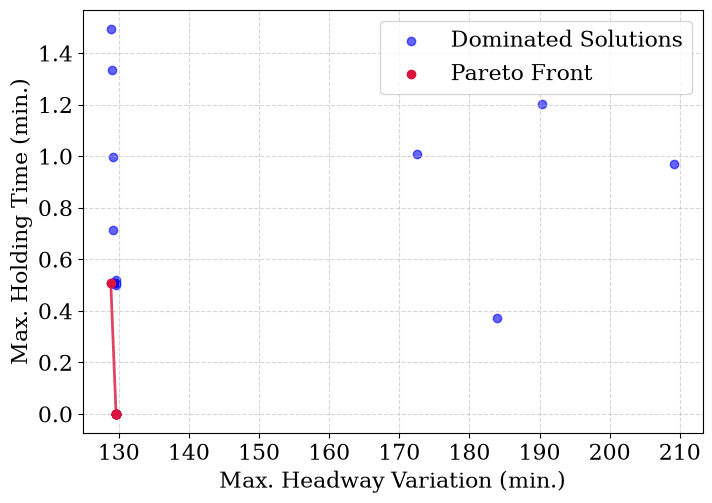

In [15]:
# Plot Pareto front
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16

fitness = -numpy.array(ga_ours.last_generation_fitness)
is_pareto = numpy.ones(fitness.shape[0], dtype=bool)
for idx, sol_fitness in enumerate(fitness):
    if is_pareto[idx]:
        is_pareto[is_pareto] = numpy.any(fitness[is_pareto] < sol_fitness, axis=1) | numpy.all(fitness[is_pareto] == sol_fitness, axis=1)
        is_pareto[idx] = True
pareto_front = fitness[is_pareto]

sorted_indices = numpy.argsort(pareto_front[:,0])
pareto_front_sorted = pareto_front[sorted_indices]

plt.figure(figsize=(8, 5.5))
plt.scatter(
    fitness[:,0],
    fitness[:,1],
    color='blue',
    alpha=0.6,
    label='Dominated Solutions'
)
plt.scatter(
    pareto_front_sorted[:,0],
    pareto_front_sorted[:,1],
    color='crimson',
    zorder=3,
    label='Pareto Front'
)
plt.plot(
    pareto_front_sorted[:,0],
    pareto_front_sorted[:,1],
    color='crimson',
    linestyle='-',
    linewidth=2,
    alpha=0.8
)

plt.xlabel("Max. Headway Variation (min.)")
plt.ylabel("Max. Holding Time (min.)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

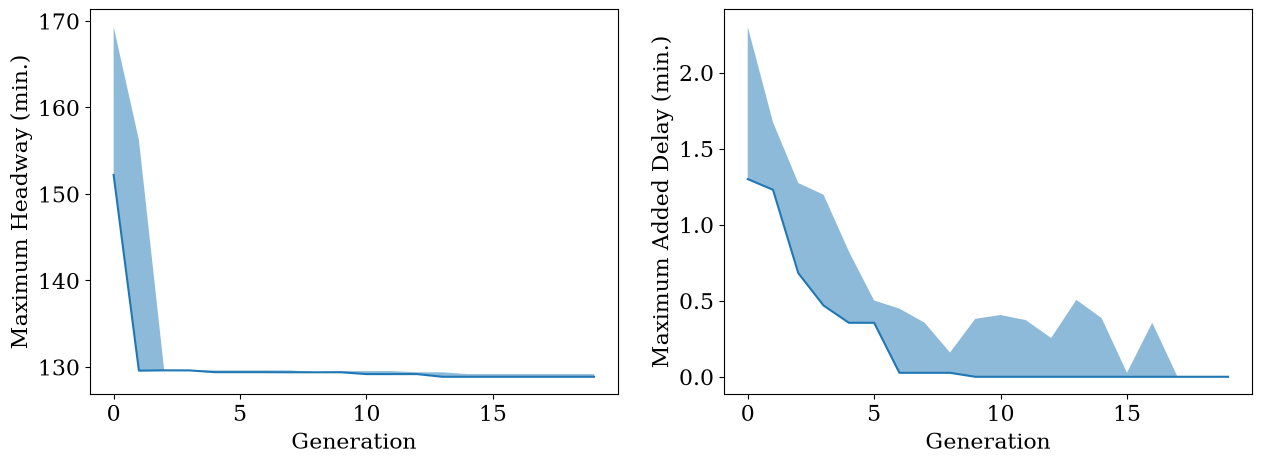

In [16]:
# Plot the fitness in the population over time to check for convergence.
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

headway_75pct = []
holding_75pct = []
headway_0pct = []
holding_0pct = []
idx = 0
while idx < len(ga_ours.solutions_fitness):
    headway_0pct.append(-max(ga_ours.solutions_fitness[idx:idx + POPULATION_SIZE], key=lambda x: x[0])[0])
    holding_0pct.append(-max(ga_ours.solutions_fitness[idx:idx + POPULATION_SIZE], key=lambda x: x[1])[1])
    headway_75pct.append(-sorted(ga_ours.solutions_fitness[idx:idx + POPULATION_SIZE], key=lambda x: x[0])[int(0.75 * POPULATION_SIZE)][0])
    holding_75pct.append(-sorted(ga_ours.solutions_fitness[idx:idx + POPULATION_SIZE], key=lambda x: x[1])[int(0.75 * POPULATION_SIZE)][1])
    idx += POPULATION_SIZE

ax[0].fill_between([i for i in range(len(headway_0pct))], headway_0pct, headway_75pct, alpha=0.5)
ax[0].plot([i for i in range(len(headway_0pct))], headway_0pct)
ax[1].fill_between([i for i in range(len(holding_0pct))], holding_0pct, holding_75pct, alpha=0.5)
ax[1].plot([i for i in range(len(holding_0pct))], holding_0pct)
ax[0].set_xlabel("Generation")
ax[1].set_xlabel("Generation")
ax[0].set_ylabel("Maximum Headway (min.)")
ax[1].set_ylabel("Maximum Added Delay (min.)")

plt.savefig(path.join('figures', 'ga_convergence.png'), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Generate a route with the winning solution for analysis
our_solution, our_solution_fitness, our_solution_idx = ga_ours.best_solution()
solution = our_solution
OUR_ROUTE = deepcopy(BASE_ROUTE)
param_idx = 1
for stop_idx in range(len(OUR_ROUTE)):
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if OUR_ROUTE[stop_idx].stop_id == ctrl_pt:
            policy = solution[param_idx]
            arg1 = solution[param_idx + 1]
            arg2 = solution[param_idx + 2]
            param_idx += 3
            if policy == 0:
                pass
            elif policy == 1:
                OUR_ROUTE[stop_idx].policy = InfiniteSchedulePolicy
                OUR_ROUTE[stop_idx].policy_args = {
                    'time_delta': N_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * N_BUSES / MIN_TRAVEL,
                    'offset': MIN_CTRL[idx] * (1 - arg2) + arg2 * MAX_CTRL[idx],
                }
            elif policy == 2:
                OUR_ROUTE[stop_idx].policy = HeadwayDrivenPolicy
                OUR_ROUTE[stop_idx].policy_args = {
                    'activation_ratio': arg1,
                    'max_holding': arg2 * MAX_HOLD,
                }

OUR_START_TIMES = [bus * solution[0] for bus in range(N_BUSES)]

## Comparison

In [18]:
# First, simulate all routes and compute headway bounds if applicable
max_headway = {'liu': 0, 'zhao': 0, 'ours': 0}
avg_headway = {'liu': [], 'zhao': [], 'ours': []}
routes = [
    RouteConfig(name=r'\text{Liu et al.}', route=LIU_ROUTE, start_times=LIU_START_TIMES),
    RouteConfig(name=r'\text{Zhao et al.}', route=ZHAO_ROUTE, start_times=ZHAO_START_TIMES),
    RouteConfig(name=r'\text{Ours}', route=OUR_ROUTE, start_times=OUR_START_TIMES),
]
results = []
for route in routes:
    print(f'Working on {route.name}...')
    headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, T_MAX)
    pr_results = simulate(route_factory(route.route), route.start_times, T_MAX)
    
    ub = []
    lb = []
    pr = []
    for stop_idx in range(len(route.route)):
        for idx, ctrl_pt in enumerate(CTRL_PTS):
            if route.route[stop_idx].stop_id == ctrl_pt:
                ub.append(headway_ub[stop_idx])
                lb.append(headway_lb[stop_idx])
                pr.append(pr_results['headway'][stop_idx])
        
        if 'liu' in route.name.lower():
            if len(pr_results['headway'][stop_idx]) > 0:
                max_headway['liu'] = max(max_headway['liu'], max(pr_results['headway'][stop_idx]))
                avg_headway['liu'].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))
        if 'zhao' in route.name.lower():
            max_headway['zhao'] = max(max_headway['zhao'], headway_ub[stop_idx])
            if len(pr_results['headway'][stop_idx]) > 0:
                avg_headway['zhao'].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))
        if 'ours' in route.name.lower():
            max_headway['ours'] = max(max_headway['ours'], headway_ub[stop_idx])
            if len(pr_results['headway'][stop_idx]) > 0:
                avg_headway['ours'].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))

    results.append(RouteResults(
        name=route.name,
        route=route.route,
        headway=HeadwayResults(upper_bound=ub, lower_bound=lb, observed=pr),
        travel_time=pr,
    ))

Working on \text{Liu et al.}...
Working on \text{Zhao et al.}...
Working on \text{Ours}...


In [19]:
# Compute headway statistics
for route in routes:
    name = route.name.split('{')[1].split('}')[0]
    print(name.upper())
    print('-' * 20)
    key = route.name.split()[0].strip('\\text{').strip('}').lower()
    print(f'Max. Headway: {max_headway[key]}')
    print(f'Avg. Headway: {sum(avg_headway[key])/len(avg_headway[key])}\n')

LIU ET AL.
--------------------
Max. Headway: 172.6903526179369
Avg. Headway: 63.4720571306968

ZHAO ET AL.
--------------------
Max. Headway: 134.82133152970965
Avg. Headway: 6.645581341656

OURS
--------------------
Max. Headway: 129.61502427692938
Avg. Headway: 6.5577538864195795



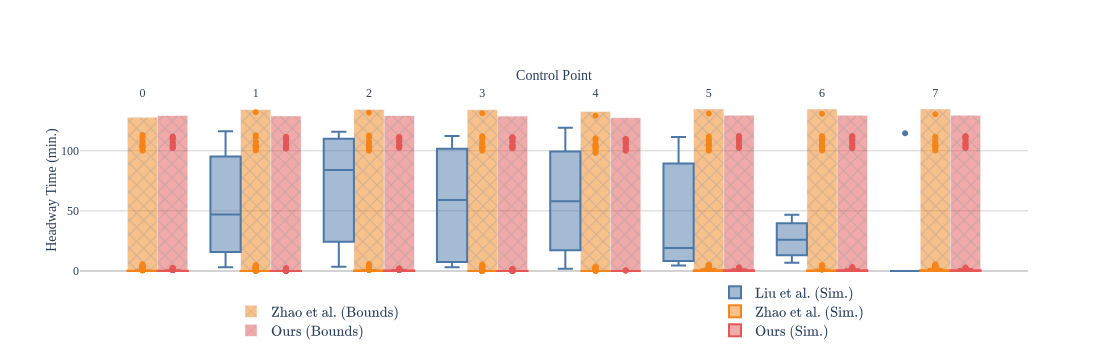

In [20]:
# Plot the headway performance at control points
fig = graph_objects.Figure()
whitespace = 0.2
width = (1 - whitespace) / len(results)

for i, result in enumerate(results):
    offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width

    for stop_idx in range(len(CTRL_PTS)):
        if "Liu" not in result.name:
            fig.add_trace(graph_objects.Bar(
                base=[result.headway.lower_bound[stop_idx]],
                legend='legend1',
                marker={'color': express.colors.qualitative.T10[i]},
                marker_pattern_shape='x',
                name='$' + result.name + r'\textrm{ (Bounds)}' + '$',
                opacity=0.5,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset],
                y=[result.headway.upper_bound[stop_idx]],
            ))
        fig.add_trace(graph_objects.Box(
            legend='legend2',
            marker={'color': express.colors.qualitative.T10[i]},
            name='$' + result.name + r'\textrm{ (Sim.)}' + '$',
            opacity=1.0,
            showlegend=True if stop_idx == 1 else False,
            width=width,
            x=[stop_idx + offset] * len(result.headway.observed[stop_idx]),
            y=result.headway.observed[stop_idx],
        ))

fig.update_layout(
    # General style
    font_family='Times New Roman, serif',
    plot_bgcolor='white',

    # Dimensions
    height=360,
    width=750,
    
    # Axes
    xaxis=dict(
        side='top',
        tickmode='array',
        tickvals=[i for i in range(len(CTRL_PTS))],
        title='Control Point',
        title_standoff=0.0,
    ),
    yaxis=dict(
        gridcolor='lightgrey',
        showgrid=True,
        title='Headway Time (min.)',
        title_standoff=0.0,
        zeroline=True,
        zerolinecolor='lightgrey',
    ),

    # Legends
    legend1=dict(
        orientation='v',
        x=0.25,
        xanchor='center',
        y=-0.12 * len(results),
        yanchor='bottom',
    ),
    legend2=dict(
        orientation='v',
        x=0.75,
        xanchor='center',
        y=-0.12 * len(results),
        yanchor='bottom',
    ),
)

fig.show()
fig.write_image(path.join('figures', 'route_optimization.pdf'))